In [ ]:
# Student Performance Prediction Using Linear Regression

## Project Objective

Predict student exam scores based on study hours using Machine Learning.

## Key Steps Performed

* Data Exploration (EDA)
* Missing Value Check
* Duplicate Check
* One-Hot Encoding
* Outlier Detection using Boxplot
* Outlier Removal using IQR Method
* Train-Test Split
* Linear Regression Model Training
* Prediction and Evaluation
* Data Visualization

## Technologies Used

Python, Pandas, NumPy, Matplotlib, Scikit-learn

## Conclusion

The model successfully learned the relationship between study hours and exam scores and generated accurate predictions.


In [2]:
import pandas as pd
import numpy as np

In [3]:
data = {
    'Student': ['A','B','C','D','E','F','G','H','I','J'],
    'Department': ['Science','Commerce','Science','Arts','Commerce',
                   'Science','Arts','Commerce','Science','Arts'],
    'Study_Hours': [2,3,4,5,6,7,8,9,10,50],
    'Exam_Score': [40,45,50,55,60,70,75,80,85,300]
}

df = pd.DataFrame(data)

df

,Student,Department,Study_Hours,Exam_Score
0,A,Science,2,40
1,B,Commerce,3,45
2,C,Science,4,50
3,D,Arts,5,55
4,E,Commerce,6,60
5,F,Science,7,70
6,G,Arts,8,75
7,H,Commerce,9,80
8,I,Science,10,85
9,J,Arts,50,300


In [4]:
df.head()

,Student,Department,Study_Hours,Exam_Score
0,A,Science,2,40
1,B,Commerce,3,45
2,C,Science,4,50
3,D,Arts,5,55
4,E,Commerce,6,60


In [6]:
print(type(df))

<class 'pandas.core.frame.DataFrame'>


In [7]:
df.tail()

,Student,Department,Study_Hours,Exam_Score
5,F,Science,7,70
6,G,Arts,8,75
7,H,Commerce,9,80
8,I,Science,10,85
9,J,Arts,50,300


In [8]:
df.shape

(10, 4)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Student      10 non-null     object
 1   Department   10 non-null     object
 2   Study_Hours  10 non-null     int64 
 3   Exam_Score   10 non-null     int64 
dtypes: int64(2), object(2)
memory usage: 452.0+ bytes


In [ ]:
#Study_Hours max = 50
#Exam_Score max = 300
#This look suspicious

In [10]:
df.isnull().sum()

Student        0
Department     0
Study_Hours    0
Exam_Score     0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df['Department'].unique()

array(['Science', 'Commerce', 'Arts'], dtype=object)

In [13]:
df['Department'].value_counts()

Department
Science     4
Commerce    3
Arts        3
Name: count, dtype: int64

In [14]:
df_encoded = pd.get_dummies(df,
                            columns=['Department'],
                            dtype=int)

df_encoded

,Student,Study_Hours,Exam_Score,Department_Arts,Department_Commerce,Department_Science
0,A,2,40,0,0,1
1,B,3,45,0,1,0
2,C,4,50,0,0,1
3,D,5,55,1,0,0
4,E,6,60,0,1,0
5,F,7,70,0,0,1
6,G,8,75,1,0,0
7,H,9,80,0,1,0
8,I,10,85,0,0,1
9,J,50,300,1,0,0


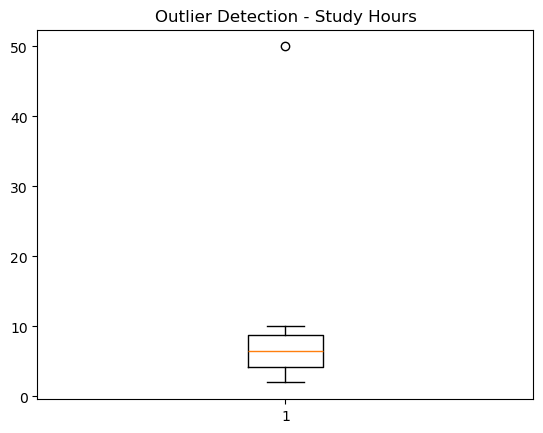

In [15]:
import matplotlib.pyplot as plt

plt.boxplot(df['Study_Hours'])
plt.title("Outlier Detection - Study Hours")
plt.show()

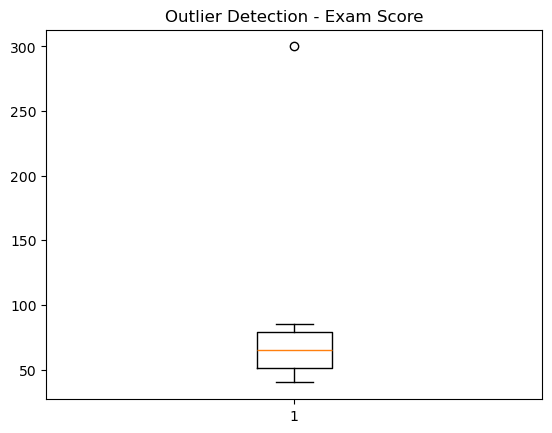

In [16]:
plt.boxplot(df['Exam_Score'])
plt.title("Outlier Detection - Exam Score")
plt.show()

In [19]:
Q1 = df['Study_Hours'].quantile(0.25)
Q3 = df['Study_Hours'].quantile(0.75)

IQR = Q3 - Q1

print("Q1 =", Q1)
print("Q3 =", Q3)
print("IQR =", IQR)

Q1 = 4.25
Q3 = 8.75
IQR = 4.5


In [21]:
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print("Lower Limit =", lower_limit)
print("Upper Limit =", upper_limit)

Lower Limit = -2.5
Upper Limit = 15.5


In [22]:
outliers = df[
    (df['Study_Hours'] < lower_limit) |
    (df['Study_Hours'] > upper_limit)
]

outliers

,Student,Department,Study_Hours,Exam_Score
9,J,Arts,50,300


In [23]:
df_clean = df[
    (df['Study_Hours'] >= lower_limit) &
    (df['Study_Hours'] <= upper_limit)
]

df_clean

,Student,Department,Study_Hours,Exam_Score
0,A,Science,2,40
1,B,Commerce,3,45
2,C,Science,4,50
3,D,Arts,5,55
4,E,Commerce,6,60
5,F,Science,7,70
6,G,Arts,8,75
7,H,Commerce,9,80
8,I,Science,10,85


In [24]:
df.shape

(10, 4)

In [25]:
df_clean.shape

(9, 4)

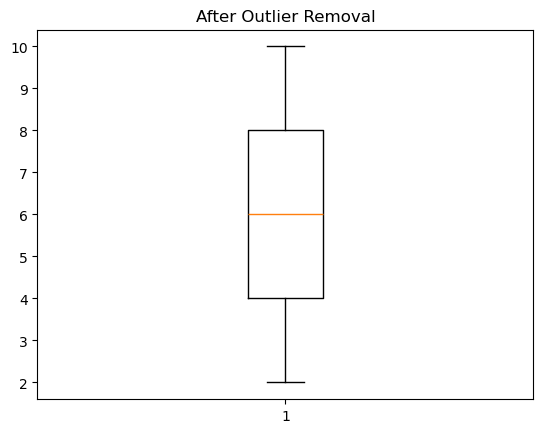

In [26]:
import matplotlib.pyplot as plt

plt.boxplot(df_clean['Study_Hours'])
plt.title("After Outlier Removal")
plt.show()

In [27]:
X = df_clean[['Study_Hours']]
y = df_clean['Exam_Score']

print(X.head())
print(y.head())

   Study_Hours
0            2
1            3
2            4
3            5
4            6
0    40
1    45
2    50
3    55
4    60
Name: Exam_Score, dtype: int64


In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [29]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (7, 1)
X_test: (2, 1)
y_train: (7,)
y_test: (2,)


In [30]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [31]:
predictions = model.predict(X_test)

print(predictions)

[79.64285714 44.64285714]


In [32]:
comparison = pd.DataFrame({
    'Actual': y_test,
    'Predicted': predictions
})

comparison

,Actual,Predicted
7,80,79.642857
1,45,44.642857


In [33]:
score = model.score(X_test, y_test)

print("R² Score:", score)

R² Score: 0.9995835068721366


In [34]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, predictions)

print("MAE =", mae)

MAE = 0.3571428571428541


In [35]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, predictions)

print("MSE =", mse)

MSE = 0.12755102040816108


In [36]:
import numpy as np

rmse = np.sqrt(mse)

print("RMSE =", rmse)

RMSE = 0.3571428571428541


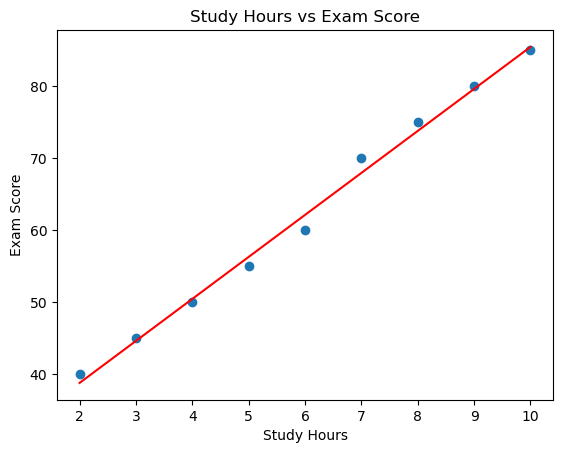

In [37]:
import matplotlib.pyplot as plt

plt.scatter(X, y)

plt.plot(X,
         model.predict(X),
         color='red')

plt.xlabel("Study Hours")
plt.ylabel("Exam Score")
plt.title("Study Hours vs Exam Score")

plt.show()